In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
csv_path = '/content/drive/MyDrive/dataset/quantum_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,q_real_0,q_real_1,q_real_2,q_real_3,q_real_4,q_real_5,q_real_6,q_real_7,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0.326759,-0.376410,0.018010,0.257298,0.249678,-0.687701,-0.358926,0.144632,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,0.390267,-0.775890,0.057996,0.001370,0.231710,-0.379083,-0.091832,-0.191034,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,0.118149,-0.693368,0.030770,0.099597,0.286569,-0.608399,-0.144325,-0.145995,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,0.308928,-0.376906,0.070070,0.276563,0.318926,-0.693181,-0.304230,-0.079621,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,0.310015,-0.517832,0.068154,0.172262,0.285593,-0.644275,-0.318354,-0.058468,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:
df.describe()

,q_real_0,q_real_1,q_real_2,q_real_3,q_real_4,q_real_5,q_real_6,q_real_7,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.385011,-0.690265,-0.009520,-0.064757,0.151091,-0.202131,0.098274,0.019797,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,0.168548,0.138050,0.160763,0.180598,0.130655,0.234765,0.250466,0.237570,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-0.301088,-0.963188,-0.454725,-0.667747,-0.270887,-0.744411,-0.584613,-0.317100,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,0.301946,-0.773800,-0.126458,-0.178881,0.057765,-0.371297,-0.071743,-0.156878,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,0.412431,-0.725418,-0.011122,-0.019974,0.150505,-0.167967,0.142788,-0.053006,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,0.497727,-0.642495,0.114953,0.069566,0.237824,-0.052334,0.304758,0.135131,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,0.769482,0.190624,0.529325,0.287937,0.667619,0.355180,0.510730,0.969094,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
q_features = ["q_real_0", "q_real_1", "q_real_2", "q_real_3",
              "q_real_4", "q_real_5", "q_real_6", "q_real_7"]

# Target columns
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

# Select features and targets
X = df[q_features]
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (98664, 8)
y shape: (98664, 5)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# Scale inputs
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

# Scale outputs (independently for each parameter!)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(len(target_cols))
])


model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='mse',
              metrics=['mae'])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,317 (177.02 KB)

 Trainable params: 44,549 (174.02 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.4383 - mae: 0.4994 - val_loss: 0.2557 - val_mae: 0.3763 - learning_rate: 5.0000e-04
Epoch 2/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2553 - mae: 0.3771 - val_loss: 0.2229 - val_mae: 0.3474 - learning_rate: 5.0000e-04
Epoch 3/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2318 - mae: 0.3550 - val_loss: 0.2101 - val_mae: 0.3322 - learning_rate: 5.0000e-04
Epoch 4/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2174 - mae: 0.3405 - val_loss: 0.2011 - val_mae: 0.3230 - learning_rate: 5.0000e-04
Epoch 5/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2094 - mae: 0.3314 - val_loss: 0.1947 - val_mae: 0.3164 - learning_rate: 5.0000e-04
Epoch 6/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2030 - mae: 0.3248 - val_loss: 0.1943 - val_mae: 0.3156 - learning_rate: 5.0000e-04
Epoch 7/300
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1965 - mae: 0.3183 - val_loss: 0.1851 - val_mae: 0.3049

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.1291595697402954
Test MAE: 0.24036332964897156


In [ ]:
y_pred = model.predict(X_test)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("\n Metrics per Atmospheric Parameter:")
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test_rescaled[:, i], y_pred_rescaled[:, i]))
    mae  = mean_absolute_error(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    r2   = r2_score(y_test_rescaled[:, i], y_pred_rescaled[:, i])
    print(f"{col}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")


 Metrics per Atmospheric Parameter:
log_H2O: RMSE=0.660, MAE=0.462, R²=0.895
log_CO2: RMSE=0.357, MAE=0.254, R²=0.969
log_CO: RMSE=1.109, MAE=0.809, R²=0.701
log_CH4: RMSE=0.609, MAE=0.419, R²=0.910
log_NH3: RMSE=0.695, MAE=0.488, R²=0.880


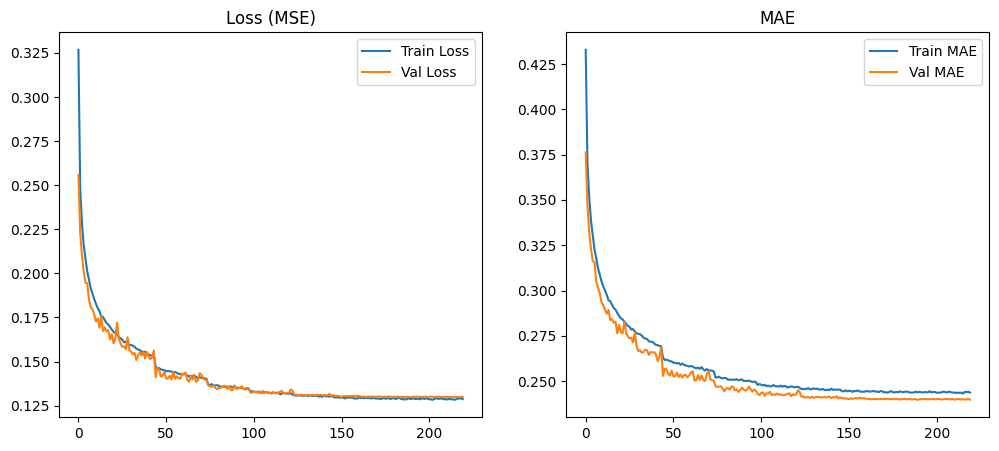

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss (MSE)")

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend(); plt.title("MAE")
plt.show()

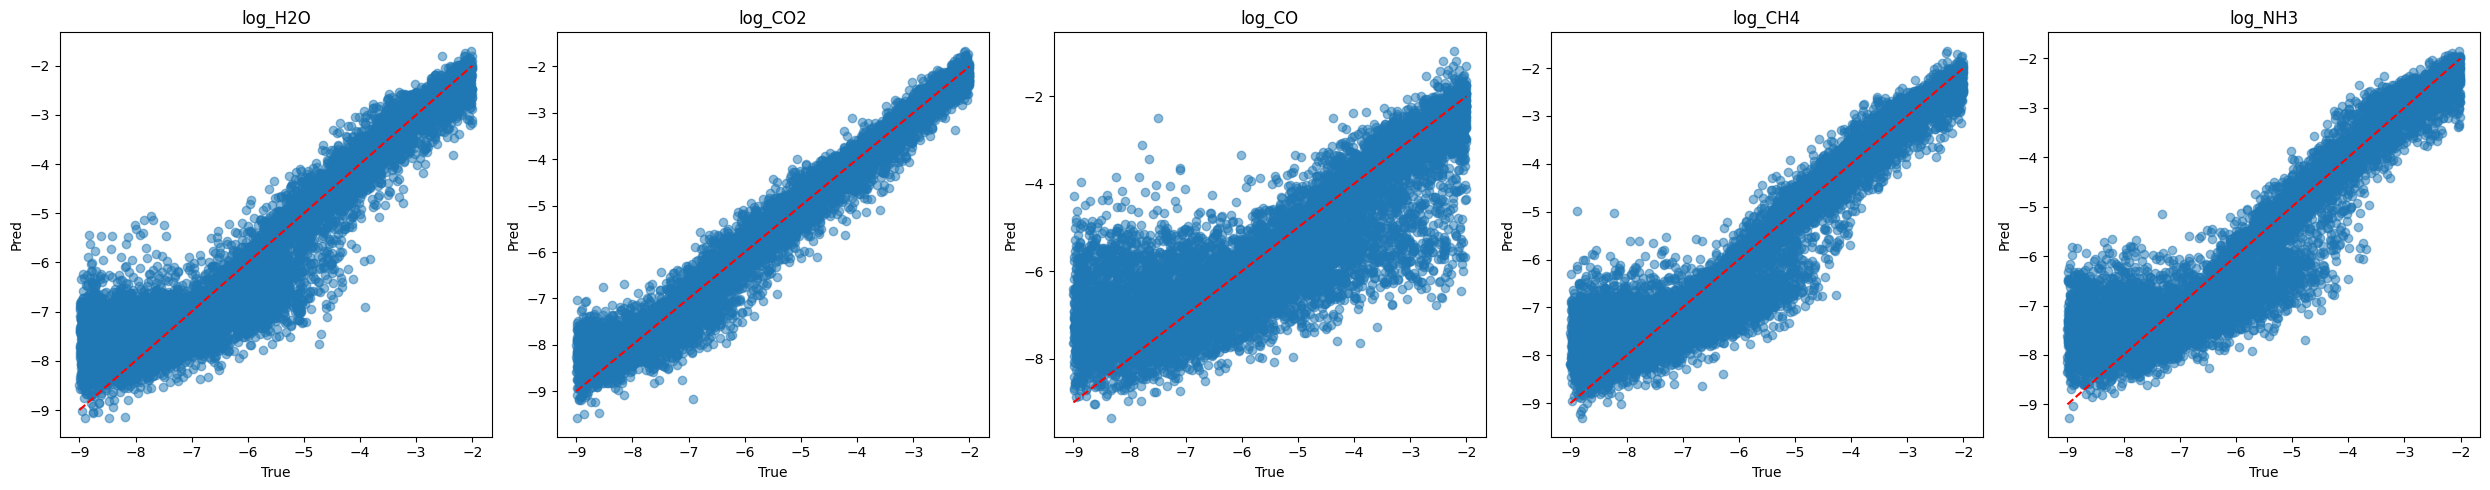

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))
for i, col in enumerate(target_cols):
    axes[i].scatter(y_test_rescaled[:, i], y_pred_rescaled[:, i], alpha=0.5)
    axes[i].plot([y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()],
                 [y_test_rescaled[:, i].min(), y_test_rescaled[:, i].max()], 'r--')
    axes[i].set_title(col)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Pick 15 random indices
indices = np.random.choice(len(X_test), size=15, replace=False)

print("\nPredictions on 15 random test samples:\n")

for idx in indices:
    sample = X_test[idx].reshape(1, -1)
    y_pred = model.predict(sample, verbose=0)

    y_pred_rescaled = scaler_y.inverse_transform(y_pred)
    y_true_rescaled = scaler_y.inverse_transform(y_test[idx].reshape(1, -1))

    print(f"Sample {idx}:")
    for i, col in enumerate(target_cols):
        print(f"  {col}: Pred={y_pred_rescaled[0][i]:.3f}, True={y_true_rescaled[0][i]:.3f}")
    print("-"*50)



Predictions on 15 random test samples:

Sample 9184:
  log_H2O: Pred=-7.693, True=-7.756
  log_CO2: Pred=-7.784, True=-8.033
  log_CO: Pred=-2.053, True=-2.170
  log_CH4: Pred=-4.503, True=-4.301
  log_NH3: Pred=-7.830, True=-7.590
--------------------------------------------------
Sample 1591:
  log_H2O: Pred=-3.048, True=-4.083
  log_CO2: Pred=-5.566, True=-6.805
  log_CO: Pred=-7.566, True=-7.475
  log_CH4: Pred=-6.439, True=-5.953
  log_NH3: Pred=-3.142, True=-4.230
--------------------------------------------------
Sample 8956:
  log_H2O: Pred=-4.251, True=-4.131
  log_CO2: Pred=-4.196, True=-4.098
  log_CO: Pred=-6.165, True=-5.254
  log_CH4: Pred=-7.368, True=-7.960
  log_NH3: Pred=-6.690, True=-5.822
--------------------------------------------------
Sample 3432:
  log_H2O: Pred=-6.748, True=-4.491
  log_CO2: Pred=-8.173, True=-8.039
  log_CO: Pred=-7.452, True=-7.947
  log_CH4: Pred=-2.691, True=-2.028
  log_NH3: Pred=-7.080, True=-7.863
--------------------------------------

In [ ]:
# import os

# save_dir = "/content/drive/MyDrive/saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Save in Keras format
# model.save(os.path.join(save_dir, "quantum_regression_model.keras"))

# #  save in H5 format
# model.save(os.path.join(save_dir, "quantum_regression_model.h5"))


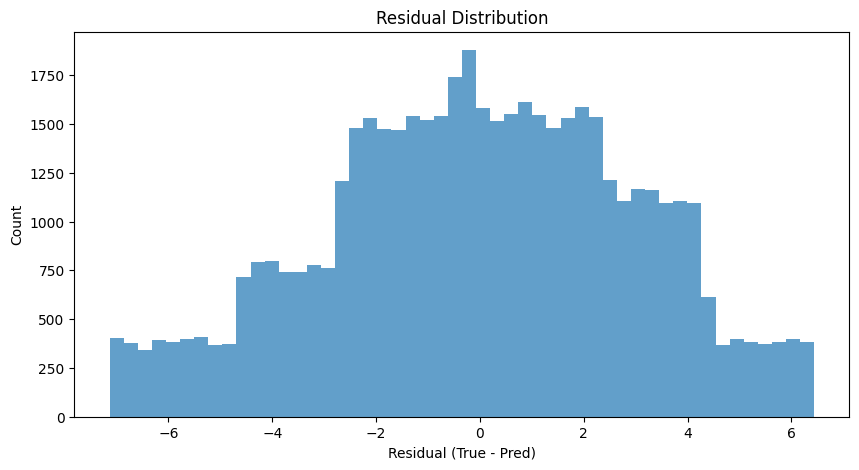

In [ ]:
residuals = y_test_rescaled - y_pred_rescaled
plt.figure(figsize=(10,5))
plt.hist(residuals.flatten(), bins=50, alpha=0.7)
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()


In [ ]:
y_shuffled = np.random.permutation(y_train)

# Train again for a few epochs with shuffled labels
history_shuf = model.fit(
    X_train, y_shuffled,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=1
)

# Evaluate performance
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Performance with shuffled labels -> Loss:", loss, "MAE:", mae)

Epoch 1/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.8451 - mae: 1.1097 - val_loss: 0.1323 - val_mae: 0.2430
Epoch 2/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7938 - mae: 1.0942 - val_loss: 0.1358 - val_mae: 0.2480
Epoch 3/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7602 - mae: 1.0846 - val_loss: 0.1405 - val_mae: 0.2555
Epoch 4/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7257 - mae: 1.0751 - val_loss: 0.1467 - val_mae: 0.2642
Epoch 5/5
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.6974 - mae: 1.0674 - val_loss: 0.1541 - val_mae: 0.2743
Performance with shuffled labels -> Loss: 0.15516844391822815 MAE: 0.27684345841407776
